In [ ]:
# 노트북 파일을 로컬에서 만든 후 clone한 폴더로 이동

# !mv /content/Simulation.ipynb /content/drive/MyDrive/study_DataTechniques/04.\ Numerical\ Simulation/simulation.ipynb

## 수치 시뮬레이션

: 수학적 모델을 사용하여 물리적 현상이나 시스템을 컴퓨터로 모의 실험하는 것을 의미합니다.                
   주로 수치해석학(numerical analysis) 기법을 활용하여 근사해를 구하는 과정을 포함합니다.           
                   
: 미래 예측을 위한 선택지를 늘려가는 방법           

고객의 소리)               
물류 비용 개선에서 다양한 것을 알 수 있었습니다. 이번에는 우리 회사 **"제품의 판매를 예측할 수 있는지"**를 검토해줬으면 합니다. 우리 제품은 대대적인 홍보를 하지는 않지만 거의 **SNS를 통해 입소문**을 타고 퍼지고 있습니다. **재구매 고객은 우리와 SNS로 연결돼** 있어 파악이 가능합니다. 이것을 이용해 앞으로의 매출을 예측할 수 있을까요?

데이터)                   
              
links.csv : 재구매 고객 20명 간 SNS 연결 상태(0 : 연결X, 1 : 연결O)                  
links_members.csv : 모든 재구매 고객 540명의 SNS 연결 상태                 
info_members.csv : 모든 재구매 고객 540명의 2년간 월별 이용 현황(0 : 이용 실적 X, 1 : 이용 실적 O)

## 인간관계 네트워크 가시화

In [5]:
from google.colab import drive
drive.mount('/content/drive') # content/임시공간

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !ls "/content/drive/MyDrive/Colab Notebooks/4장_data"

In [1]:
import pandas as pd

df_links = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/4장_data/links.csv", index_col = 0)
df_links.head()

# 1 : 연결되어 있다
# 0 : 연결되어 있지 않다

,Node0,Node1,Node2,Node3,Node4,Node5,Node6,Node7,Node8,Node9,Node10,Node11,Node12,Node13,Node14,Node15,Node16,Node17,Node18,Node19
Node0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Node1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
Node2,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Node3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Node4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## SNS 연결 가시화

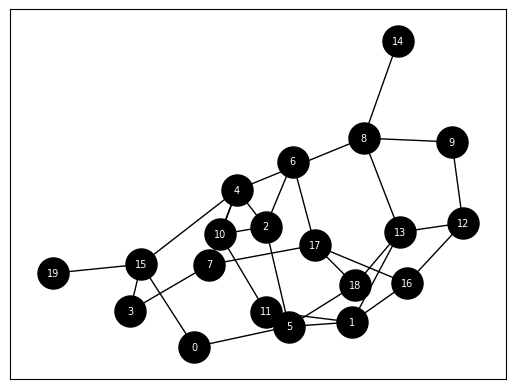

In [57]:
# network를 이용한 가시화
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

node_list = []
for i in range(len(df_links.columns)) :
  node_nm =df_links.columns[i].split("Node")[1]
  G.add_node(node_nm)
  node_list.append(node_nm)

# weights_list = []
for i in range(len(df_links.index)) :
  for j in range(len(df_links.columns)) :
    if df_links.iloc[i, j] == 1 :
      G.add_edge(node_list[i], node_list[j])
      # weights_list.append(df_links.iloc[i, j])

# pos = {}

nx.draw_networkx(G, with_labels= True, font_color = 'w', node_color= 'k', node_size= 500, font_size= 7)
plt.show()

# 네트워크 가시화에서 이전에 사용한 draw가 아닌 draw_networkx를 사용합니다.
# 이 함수는 *다른 것과 연결이 많은 노드를 중심에 오게* 자동으로 위치를 결정해서 가시화합니다.
# 재현성이 없기 때문에 실행할 때마다 다른 그래프가 표시되지만
# 모든 노드로부터 연결이 있는 노드에 대해 정확하게 엣지가 연결되어 있으면 가시화는 성공이라고 할 수 있습니다.

In [49]:
# dir(nx.Graph) # add_edge, add_node,
# dir(nx) # draw_networkx

In [54]:
# # 교재)
# import networkx as nx
# import matplotlib.pyplot as plt

# G = nx.Graph()

# num = len(df_links.index)

# for i in range(num) :
#   node_no = df_links.columns[i].strip("Node")
#   G.add_node(str(node_no))

# for i in range(num) :
#   for j in range(num) :
#     node_nm = 'Node' + str(j)
#     if df_links[node_nm].iloc[i] == 1 :
#       G.add_edge(str(i), str(j))

# # 그리기
# nx.draw_networkx(G,node_color= 'k', edge_color= 'k', font_color= 'w')
# plt.show()

## 입소문에 의한 정보 전파 모습 가시화

In [ ]:
# 불러 온 네트워크 구조를 이용해 입소문이 전파되는 모습을 시뮬레이션
# 가정 : 10개의 연결 중 하나의 확률(10%의 확률)로 소문이 전파된다.

